In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter
from imblearn.over_sampling import SMOTE


In [2]:
BATCH_SIZE = 8
IMG_SIZE = (160, 160)

In [3]:
IMAGES_DIR = "../data/images"
MASKS_DIR = "../data/masks/"
CSV_PATH = "../data/GroundTruth.csv"

In [4]:
metadata = pd.read_csv(CSV_PATH)

print(metadata.head())
print(metadata.info())

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), str(1)
memory usage: 626.1 KB
None


#### CLASSES

As sete classes utilizadas são:

- **MEL:** Melanoma
- **NV:** Nevos Melanocíticos
- **BCC:** Carcinoma Basocelular
- **AKIEC:** Queratose Actínica
- **BKL:** Queratose Benigna
- **DF:** Dermatofibroma
- **VASC:** Lesão Vascular

São criados dois dicionários:

- `class_code`: nome da classe para número
- `class_name`: número para nome da classe

In [5]:
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

class_code = {label: code for code, label in enumerate(classes)}
class_name = {code: label for code, label in enumerate(classes)}

print(class_code)
print(class_name)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}
{0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'AKIEC', 4: 'BKL', 5: 'DF', 6: 'VASC'}


### CRIAÇÃO DOS RÓTULOS CODIFICADOS

A função abaixo lê os nomes das imagens disponíveis na pasta `data/images`, cruza esses nomes com o arquivo `GroundTruth.csv` e transforma a classe de cada imagem em um valor inteiro.

Esse formato é necessário porque a CNN será treinada com `SparseCategoricalCrossEntropy`.

In [6]:
def get_coded_labels(directory, metadata, class_code):
    image_names = [
        x.rsplit(".", 1)[0]
        for x in os.listdir(directory)
        if x.lower().endswith((".jpg", ",jpeg", ".png"))
    ]

    image_df = pd.DataFrame({"image": sorted(image_names)})

    merged = image_df.merge(metadata, on="image", how="inner")

    coded_labels = merged[classes].idxmax(axis=1).map(lambda x: class_code[x])

    return list(coded_labels)

### CRIAÇÃO DO DATASET

O dataset é criado redimensionando todas as imagens, associando cada imagem ao seu rótulo numérico e convertendo-as em um objeto `tf.data.Dataset`.

In [7]:
dataset = keras.utils.image_dataset_from_directory(
    directory=IMAGES_DIR,
    labels=get_coded_labels(IMAGES_DIR, metadata, class_code),
    batch_size=None,
    label_mode="int",
    shuffle=True,
    image_size=IMG_SIZE
)

Found 10015 files belonging to 7 classes.


In [8]:
# Separação correta dos dados:
# 70% treino, 15% validação e 15% teste.
# O conjunto de teste fica reservado apenas para a avaliação final.

train_ds_raw, temp_ds = keras.utils.split_dataset(
    dataset,
    left_size=0.7,
    shuffle=True,
    seed=42
)

val_ds_raw, test_ds_raw = keras.utils.split_dataset(
    temp_ds,
    left_size=0.5,
    shuffle=True,
    seed=42
)


### BALANCEAMENTO COM SMOTE, DATA AUGMENTATION E RESNET50

Após a separação em treino, validação e teste, o SMOTE é aplicado **somente ao conjunto de treino**, evitando vazamento de dados para validação e teste.

Em seguida, o conjunto de treino balanceado é convertido novamente para `tf.data.Dataset`, embaralhado, dividido em batches e submetido ao Data Augmentation durante o treinamento.

Os conjuntos de validação e teste permanecem sem SMOTE e sem Data Augmentation. A validação é usada para monitorar o treinamento, enquanto o teste é reservado para a avaliação final.

O modelo utiliza a ResNet50 pré-treinada como extratora de características. A camada `Flatten` não é utilizada; no lugar dela, é aplicada a camada `GlobalAveragePooling2D`, reduzindo a quantidade de parâmetros antes das camadas densas.


In [9]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    
    return images, labels


In [10]:
def dataset_to_numpy(ds):
    images_list = []
    labels_list = []

    for image, label in ds:
        images_list.append(image.numpy().astype("float32"))
        labels_list.append(label.numpy())

    X = np.stack(images_list)
    y = np.array(labels_list, dtype=np.int32)

    return X, y

X_train, y_train = dataset_to_numpy(train_ds_raw)


In [11]:
print("Distribuição original do treino:")
print(Counter(y_train))

Distribuição original do treino:
Counter({np.int32(1): 4697, np.int32(4): 767, np.int32(0): 764, np.int32(2): 382, np.int32(3): 217, np.int32(6): 100, np.int32(5): 83})


In [12]:
original_train_label_counts = pd.Series(y_train).value_counts().sort_index()
original_train_label_counts.index = [class_name[i] for i in original_train_label_counts.index]

n_samples, height, width, channels = X_train.shape

X_train_flat = X_train.reshape(n_samples, -1)

smote = SMOTE(random_state=42, k_neighbors=3)

X_train_smote_flat, y_train_smote = smote.fit_resample(
    X_train_flat,
    y_train
)

X_train_smote = X_train_smote_flat.reshape(-1, height, width, channels)
X_train_smote = np.clip(X_train_smote, 0, 255).astype("float32")
y_train_smote = y_train_smote.astype("int32")

In [13]:
print("\nDistribuição do treino após SMOTE:")
print(Counter(y_train_smote))


Distribuição do treino após SMOTE:
Counter({np.int32(2): 4697, np.int32(1): 4697, np.int32(4): 4697, np.int32(0): 4697, np.int32(5): 4697, np.int32(3): 4697, np.int32(6): 4697})


In [14]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train_smote, y_train_smote))

train_ds = train_ds.shuffle(
    buffer_size=len(y_train_smote),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds = val_ds_raw.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds_raw.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


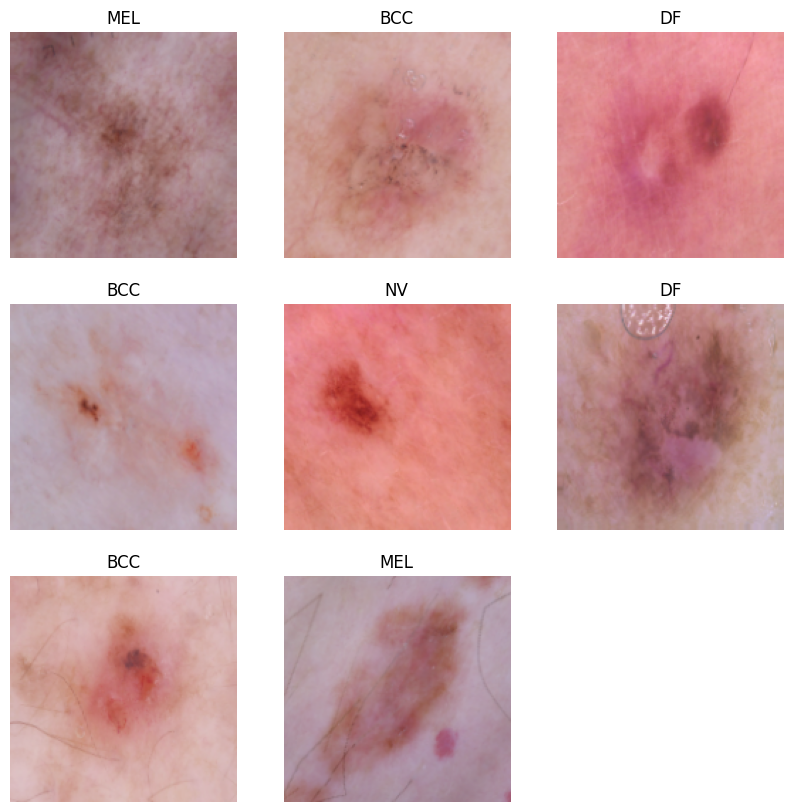

In [15]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        plt.title(class_name[int(labels[i].numpy())])
        plt.axis("off")

plt.show()

Quantidade de imagens no conjunto de treino após SMOTE: 32879


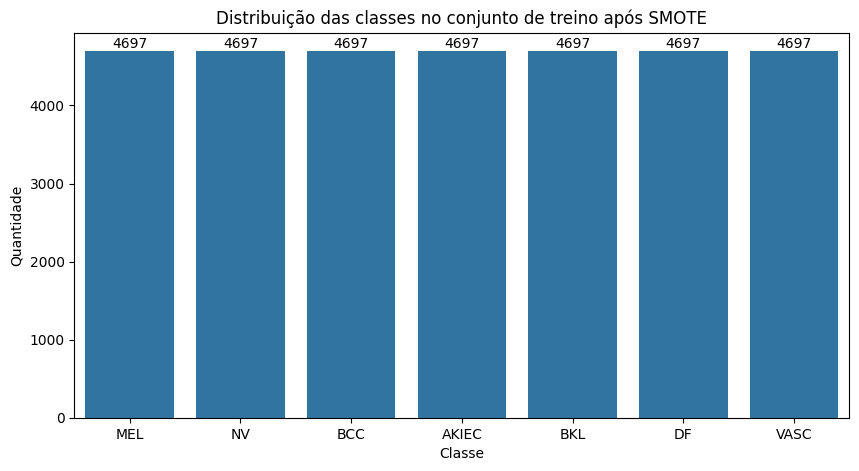

MEL      4697.0
NV       4697.0
BCC      4697.0
AKIEC    4697.0
BKL      4697.0
DF       4697.0
VASC     4697.0
dtype: object


In [16]:
train_label_df = pd.DataFrame(columns=classes)

for images, labels in train_ds.as_numpy_iterator():
    label_array = np.zeros((len(labels), len(classes)))

    for i, label in enumerate(labels):
        label_array[i, int(label)] = 1

    batch_df = pd.DataFrame(label_array, columns=classes)
    train_label_df = pd.concat([train_label_df, batch_df], ignore_index=True)

card = len(train_label_df)

print("Quantidade de imagens no conjunto de treino após SMOTE:", card)

label_counts = train_label_df.sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribuição das classes no conjunto de treino após SMOTE")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

print(label_counts)

In [17]:
# Modelo com ResNet50 pré-treinada no ImageNet
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Primeira etapa: congela a base convolucional para usar a ResNet50 como extratora de características
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = preprocess_input(inputs)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(len(classes))(x)

model = models.Model(inputs=inputs, outputs=outputs, name="cnn_smote_2")

model.summary()


Model: "cnn_smote_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 160, 160)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 160, 160)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 160, 160)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 160, 160,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 160, 160,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 5, 5,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7)         │        903 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [19]:
print("Distribuição final usada no treinamento:")
print(label_counts)

Distribuição final usada no treinamento:
MEL      4697.0
NV       4697.0
BCC      4697.0
AKIEC    4697.0
BKL      4697.0
DF       4697.0
VASC     4697.0
dtype: object


In [20]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_cnn_smote_2.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, reduce_lr, checkpoint]


In [21]:
# Etapa 1: treinamento da cabeça classificadora com a ResNet50 congelada
history = model.fit(
    train_ds,
    epochs=200,
    validation_data=val_ds,
    callbacks=callbacks
)

# Etapa 2: fine-tuning das últimas camadas da ResNet50
base_model.trainable = True

# Mantém a maior parte da ResNet50 congelada e libera apenas as últimas camadas
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks
)

# Junta os históricos das duas etapas para facilitar os gráficos e o diagnóstico final
combined_history = {}
for key in history.history.keys():
    combined_history[key] = history.history[key] + fine_tune_history.history.get(key, [])

history.history = combined_history


Epoch 1/200
4110/4110 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5038 - loss: 1.5950
Epoch 1: val_loss improved from None to 1.00609, saving model to best_cnn_smote_2.keras

Epoch 1: finished saving model to best_cnn_smote_2.keras
4110/4110 ━━━━━━━━━━━━━━━━━━━━ 534s 129ms/step - accuracy: 0.6050 - loss: 1.2675 - val_accuracy: 0.6871 - val_loss: 1.0061 - learning_rate: 1.0000e-04
Epoch 2/200
4110/4110 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7169 - loss: 0.9273
Epoch 2: val_loss improved from 1.00609 to 0.93247, saving model to best_cnn_smote_2.keras

Epoch 2: finished saving model to best_cnn_smote_2.keras
4110/4110 ━━━━━━━━━━━━━━━━━━━━ 563s 137ms/step - accuracy: 0.7309 - loss: 0.8801 - val_accuracy: 0.6811 - val_loss: 0.9325 - learning_rate: 1.0000e-04
Epoch 3/200
4110/4110 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.7618 - loss: 0.7702
Epoch 3: val_loss improved from 0.93247 to 0.86879, saving model to best_cnn_smote_2.keras

Epoch 3: finished saving model to best

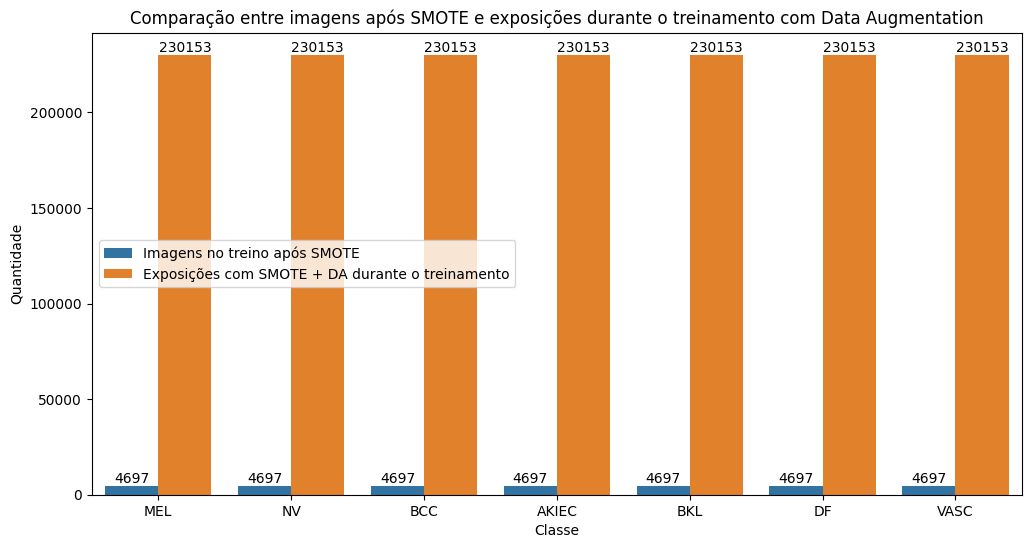

In [22]:
epochs = len(history.history["loss"])

comparison_df = pd.DataFrame({
    "Classe": label_counts.index.tolist(),
    "Imagens no treino após SMOTE": label_counts.values,
    "Exposições com SMOTE + DA durante o treinamento": (label_counts * epochs).values
})

comparison_df_melted = comparison_df.melt(
    id_vars="Classe",
    var_name="Tipo",
    value_name="Quantidade"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=comparison_df_melted,
    x="Classe",
    y="Quantidade",
    hue="Tipo"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Comparação entre imagens após SMOTE e exposições durante o treinamento com Data Augmentation")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.legend(title="")
plt.show()

In [23]:
"history" in globals()

True

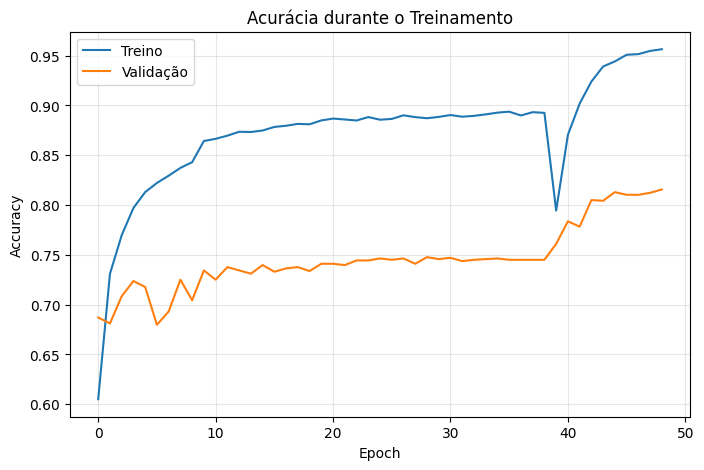

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Acurácia durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

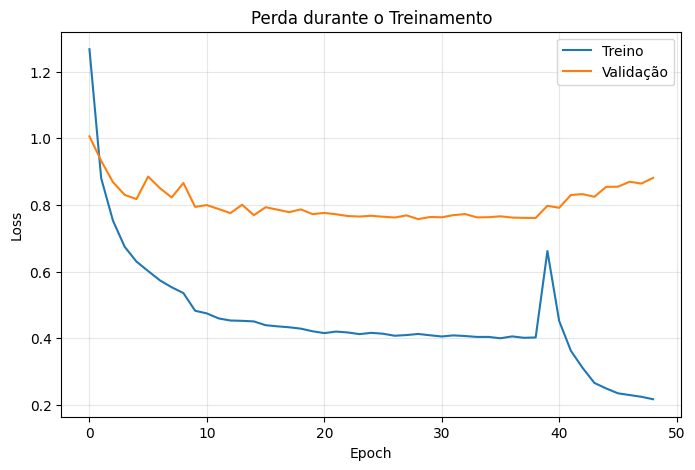

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perda durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
# Carrega o melhor modelo salvo pelo ModelCheckpoint para avaliação final no conjunto de teste
best_model = keras.models.load_model("best_cnn_smote_2.keras")

probability_model = tf.keras.Sequential([
    best_model,
    layers.Softmax()
])


In [27]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = probability_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

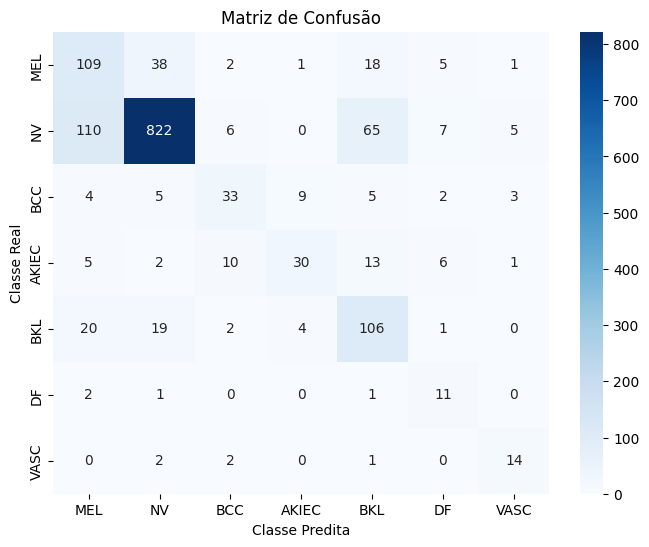

In [28]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

In [29]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("Relatório de Classificação:\n")
print(report)

Relatório de Classificação:

              precision    recall  f1-score   support

         MEL     0.4360    0.6264    0.5142       174
          NV     0.9246    0.8099    0.8634      1015
         BCC     0.6000    0.5410    0.5690        61
       AKIEC     0.6818    0.4478    0.5405        67
         BKL     0.5072    0.6974    0.5873       152
          DF     0.3438    0.7333    0.4681        15
        VASC     0.5833    0.7368    0.6512        19

    accuracy                         0.7485      1503
   macro avg     0.5824    0.6561    0.5991      1503
weighted avg     0.7917    0.7485    0.7621      1503



In [30]:
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("MÉTRICAS GERAIS DO MODELO")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nMacro Average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1-Score: {f1_macro:.4f}")
print(f"\nWeighted Average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall: {recall_weighted:.4f}")
print(f"  F1-Score: {f1_weighted:.4f}")

MÉTRICAS GERAIS DO MODELO

Accuracy: 0.7485

Macro Average:
  Precision: 0.5824
  Recall: 0.6561
  F1-Score: 0.5991

Weighted Average:
  Precision: 0.7917
  Recall: 0.7485
  F1-Score: 0.7621


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


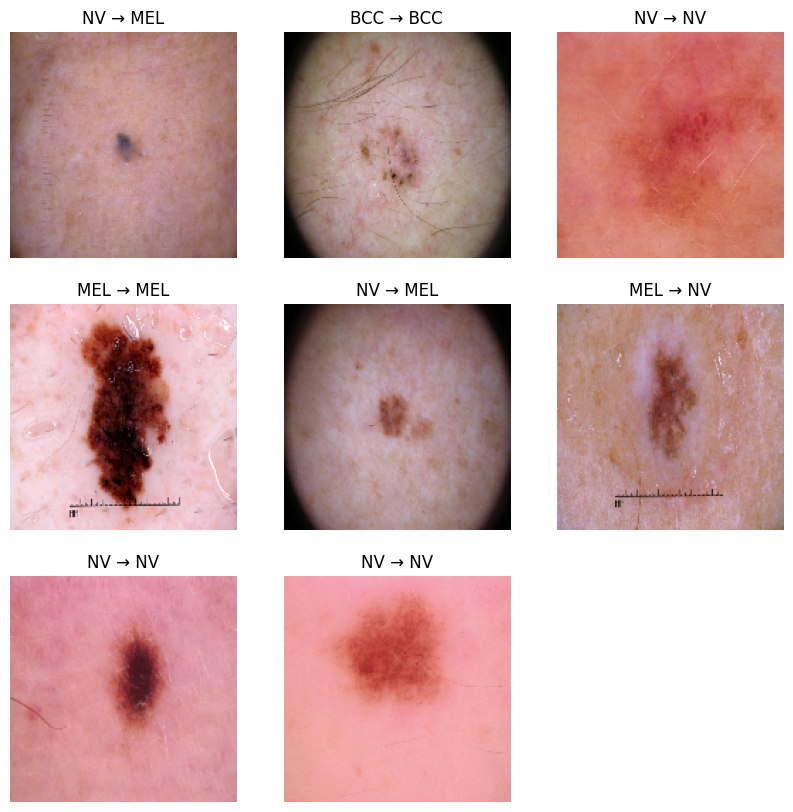

In [31]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    predictions = probability_model.predict(images)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        true_label = class_name[int(labels[i].numpy())]
        pred_label = class_name[int(np.argmax(predictions[i]))]

        plt.title(f"{true_label} → {pred_label}")
        plt.axis("off")

plt.show()

In [32]:
best_epoch = int(np.argmin(history.history["val_loss"]))

best_train_acc = history.history["accuracy"][best_epoch]
best_val_acc = history.history["val_accuracy"][best_epoch]
best_train_loss = history.history["loss"][best_epoch]
best_val_loss = history.history["val_loss"][best_epoch]

print("\nDiagnóstico final pela melhor época:")
print(f"Melhor época: {best_epoch + 1}")
print(f"Train accuracy: {best_train_acc:.4f}")
print(f"Val accuracy: {best_val_acc:.4f}")
print(f"Train loss: {best_train_loss:.4f}")
print(f"Val loss: {best_val_loss:.4f}")



Diagnóstico final pela melhor época:
Melhor época: 29
Train accuracy: 0.8871
Val accuracy: 0.7477
Train loss: 0.4131
Val loss: 0.7576
